In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output

sns.set(palette="Set2")

import torch
from torch import nn

print(torch.__version__)

2.6.0+cpu


# [Phystech@DataScience](https://thetahat.ru/courses/ph-ds-2025-spr)

In [2]:
# Bot check

# HW_ID: phds_sem11
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

**ЗАДАЧА 1**

Пользуясь функциями `torch.tensor` создайте **один** тензор, и посчитайте с его помощью сумму чисел от 1 до 100. Затем посчитайте суммы чисел в каждом десятке (от 1 до 10, от 11 до 20 и так далее)

In [3]:
tensor = torch.arange(1, 101)
print(tensor.sum())
print(tensor.view(-1, 10).sum(dim=1))

tensor(5050)
tensor([ 55, 155, 255, 355, 455, 555, 655, 755, 855, 955])


**ЗАДАЧА 2**

Нарисуйте по сетке данную кривую на графике, используя `torch`:

$$x(t) = 2 \cos t + \sin 2t \cos 60t,$$

$$y(t) = \sin 2t + \sin 60t.$$

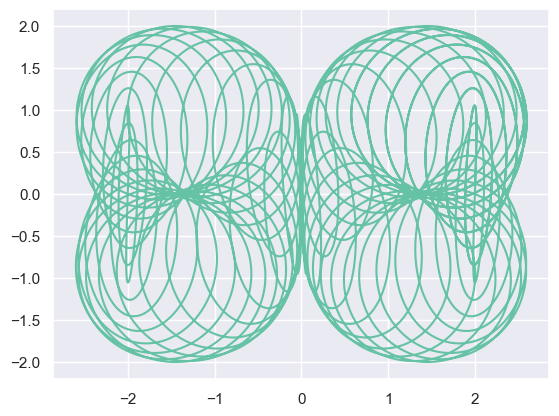

In [4]:
t = torch.linspace(0, 7, 20000)
x = 2 * torch.cos(t) + torch.sin(2 * t) * torch.cos(60 * t)
y = torch.sin(2 * t) + torch.sin(60 * t)
plt.plot(x, y)
plt.show()

Заметим, что библиотека `matplotlib` справляется с отображением `pytorch`-тензоров, и дополнительных преобразований делать не нужно.



**ЗАДАЧА 3**

Возьмите последнюю нейросеть из семинара с простыми примерами, замените функции активации на Sigmoid. Обучите получившуюся модель на тех же данных (значение MSE должно стать меньше 27). Для обучения используйте код из семинара

Как изменились итоговые предсказания? Объясните полученный результат


In [5]:
# Функция для отрисовки процесса обучения
def show_progress(
    x: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, loss: torch.Tensor
) -> None:
    """Визуализация процесса обучения.

    Параметры: 
    x (torch.Tensor): объекты обучающей выборки;
    y (torch.Tensor): таргеты обучающей выборки;
    y_pred (torch.Tensor): предсказания модели;
    loss (torch.Tensor): текущее значение ошибки модели.
    """

    # Открепим переменную от вычислительного графа перед отрисовкой графика
    y_pred = y_pred.detach()

    # Превратим тензор размерности 0 в число
    loss = loss.item()

    # Стираем предыдущий вывод в тот момент, когда появится следующий
    clear_output(wait=True)

    # Строим новый график
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.75, label="Обучающая выборка")
    plt.scatter(x, y_pred, color="orange", linewidth=5, label="Предсказания")
    plt.xlabel("% населения с низким уровнем дохода")
    plt.ylabel("Медианная стоимость домов в тыс. $")
    plt.title("Процесс обучения модели в интерактиве")
    plt.legend()
    plt.show()

    print(f"MSE = {loss:.3f}")

In [6]:
# Загрузка датасета
# ссылка для скачивания данных
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# собираем таблицу данных
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# выделяем признаки и таргет
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

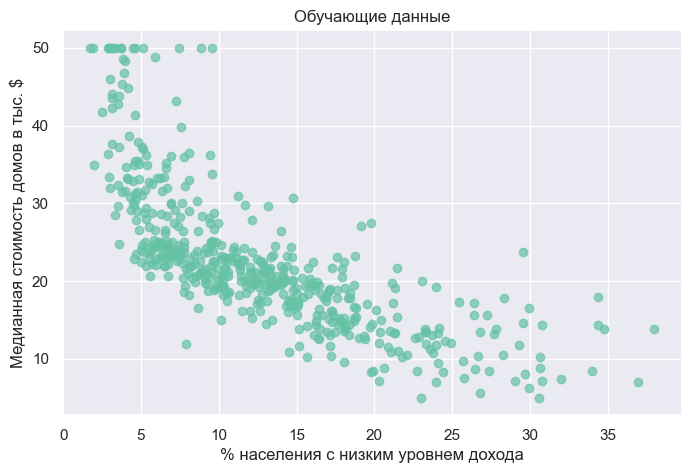

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(data[:, -1], target, alpha=0.7)
plt.xlabel("% населения с низким уровнем дохода")
plt.ylabel("Медианная стоимость домов в тыс. $")
plt.title("Обучающие данные");

In [8]:
# Модель
# собираем модули в последовательность
model = nn.Sequential(
    nn.Linear(in_features=1, out_features=16),
    nn.Sigmoid(),
    nn.Linear(in_features=16, out_features=32),
    nn.Sigmoid(),
    nn.Linear(in_features=32, out_features=1),
)

model

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

In [9]:
# Инициализация весов
for name, param in model.named_parameters():
    if "weight" in name:
        nn.init.uniform_(param, a=-0.1, b=0.1)
    elif "bias" in name:
        nn.init.constant_(param, 0.0)
param_groups = [
    {"params": [p for name, p in model.named_parameters() if "weight" in name], "lr": 0.01},
    {"params": [p for name, p in model.named_parameters() if "bias" in name], "lr": 0.05},
]

In [10]:
# Создание оптимизатора и функции потерь
optimizer = torch.optim.SGD(params=param_groups)
loss_function = nn.MSELoss()

In [11]:
def optim_func(y_pred, y_true):
    return torch.mean((y_pred - y_true) ** 2)

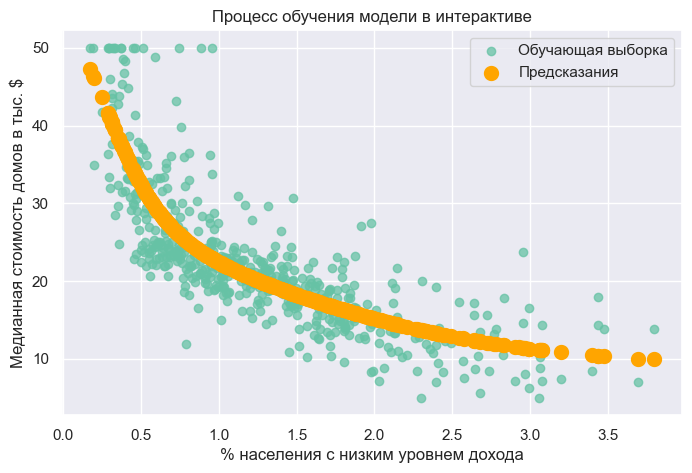

MSE = 27.000
Готово!


In [12]:
x = torch.FloatTensor(data[:, -1] / 10)
x_new = x.reshape(-1, 1)

y = torch.FloatTensor(target)
y_new = y.reshape(-1, 1)

# Обучение
# Количество итераций
num_iter = 10_000

for i in range(num_iter):

    # Forward pass: предсказание модели по данным x_new
    y_pred = model(x_new)

    # Вычисление оптимизируемой функции (MSE) по предсказаниям
    loss = optim_func(y_pred, y_new)

    # Bakcward pass: вычисление градиентов оптимизируемой функции
    # по всем параметрам модели
    loss.backward()

    # Оптимизация: обновление параметров по формулам соответствующего
    # метода оптимизации, используются вычисленные ранее градиенты
    optimizer.step()

    # Зануление градиентов
    optimizer.zero_grad()

    # График + вывод MSE через каждые 5 итераций
    if (i + 1) % 5 == 0:
        show_progress(x, y, y_pred, loss)

        if loss.item() < 27:
            print("Готово!")
            break

**Вывод:** С помощью сигмоиды получили гладкую аппроксимацию данных с нужной точностью